In [1]:
import numpy as np
import pandas as pd

Dataset Calling

In [2]:
df = pd.read_csv('/content/spam.csv', encoding='latin1')
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2705,ham,What i mean is do they come chase you out when...,NaN,NaN,NaN
3414,ham,He remains a bro amongst bros,NaN,NaN,NaN
3227,spam,"SIX chances to win CASH! From 100 to 20,000 po...",NaN,NaN,NaN
2432,ham,Really dun bluff me leh... U sleep early too. ...,NaN,NaN,NaN
3451,ham,Ugh just got outta class,NaN,NaN,NaN


Data Cleaning

In [3]:
df.shape

(5572, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
#Dropping some columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)
df.sample(5)

,v1,v2
4476,ham,Oh :-)only 4 outside players allowed to play know
1798,ham,That one week leave i put know that time. Why.
3397,ham,It only does simple arithmetic not percentages.
4589,ham,Tomorrow i am not going to theatre. . . So i c...
5527,ham,"Total disappointment, when I texted you was th..."


In [6]:
#Renaming the columns
df.rename(columns={'v1':'target', 'v2':'text'}, inplace = True)
df.sample(5)

,target,text
5014,ham,I think the other two still need to get cash b...
2237,ham,"Give her something to drink, if she takes it a..."
2408,ham,Dear where you will be when i reach there
1422,spam,Congratulations ur awarded either å£500 of CD ...
2034,ham,Is avatar supposed to have subtoitles


In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [8]:
df['target'] = encoder.fit_transform(df['target'])
df.sample(5)

,target,text
3912,0,Yeah whatever lol
3845,0,Pls go there today &lt;#&gt; . I dont want an...
4972,0,Oops I was in the shower when u called. Hey a ...
1449,0,say thanks2.
4880,0,When/where do I pick you up


In [9]:
#Missing Values
df.isnull().sum()

,0
target,0
text,0


In [10]:
#Duplicate Values
df.duplicated().sum()

np.int64(403)

In [11]:
#Removing duplicate values
df = df.drop_duplicates(keep='first')
df.duplicated().sum()
df.shape

(5169, 2)

Exploratory Data Analysis(EDA)

In [12]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df['target'].value_counts()

,count
target,
0,4516
1,653


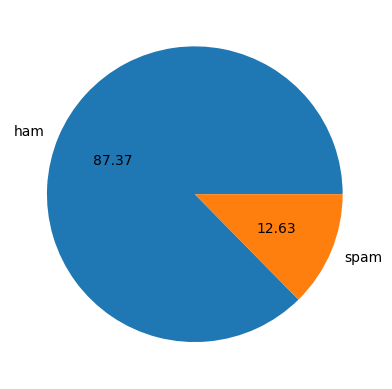

In [14]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [15]:
#Data is imbalanced

In [16]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:
#Addition of column for number of characters
df['num_char'] = df['text'].apply(len)
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
#Addition of column for number of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [19]:
#Addition of column for number of sentences
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [20]:
#Description for all messages
df[['num_char', 'num_words', 'num_sentences']].describe()

,num_char,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [21]:
#Description for ham messages
df[df['target']==0][['num_char', 'num_words', 'num_sentences']].describe()

,num_char,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [22]:
#Description for spam messages
df[df['target']==1][['num_char', 'num_words', 'num_sentences']].describe()

,num_char,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [23]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

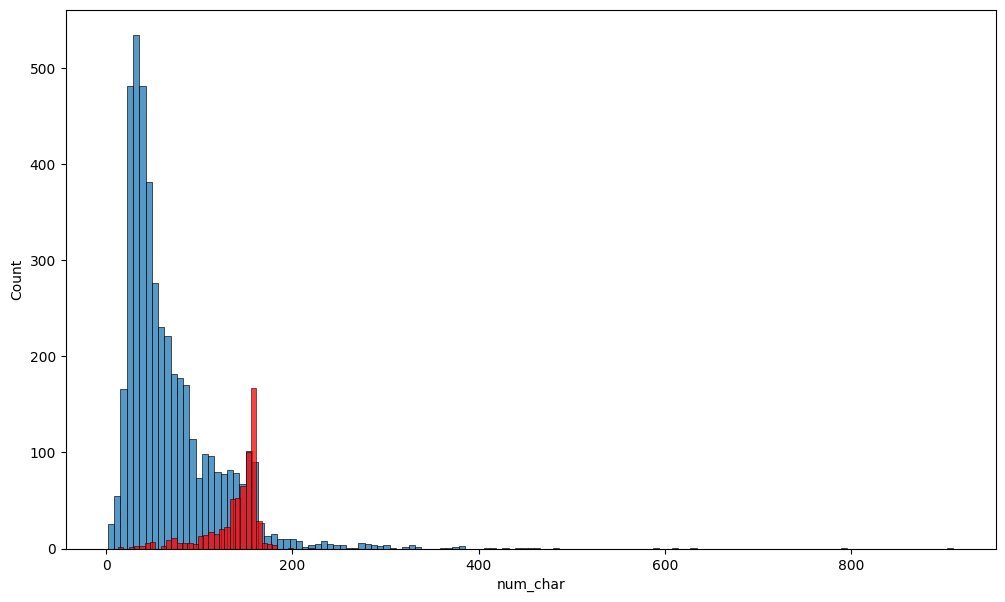

In [24]:
#Plotting a histogram for clear depiction
plt.figure(figsize=(12, 7))
sns.histplot(df[df['target']==0]['num_char'])
sns.histplot(df[df['target']==1]['num_char'], color = 'red')
#Similar pattern is observed for number of words and sentences

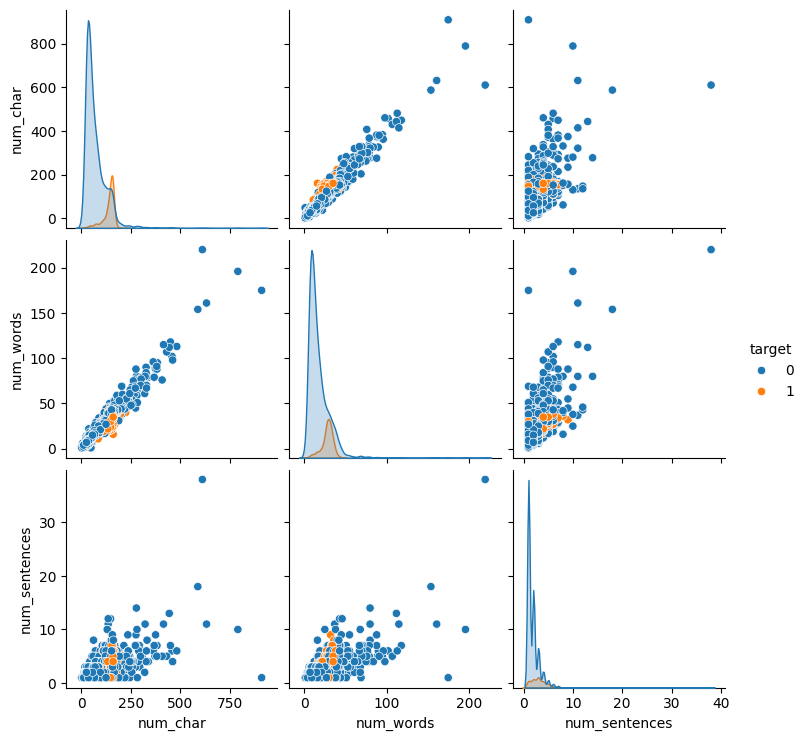

In [25]:
sns.pairplot(df, hue='target')

<Axes: >

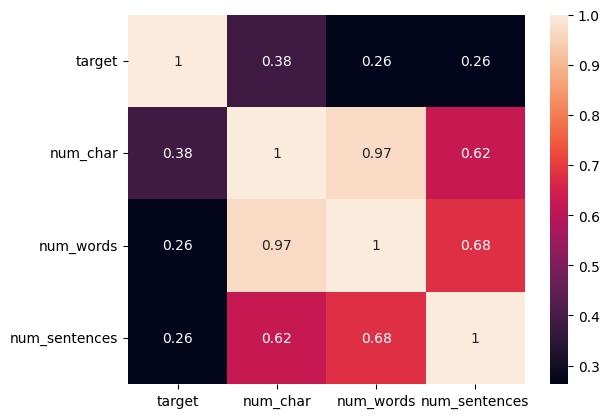

In [26]:
sns.heatmap(df[['target', 'num_char', 'num_words', 'num_sentences']].corr(), annot=True)

Text Preprocessing
- Lowercasing
- Tokenization
- Removal of special characters
- Removal of stop words and punctuations
- Stemming or Lemmetization


In [27]:
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
import string

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [28]:
def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()
  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()
  ps = PorterStemmer()
  for i in text:
    y.append(ps.stem(i))
  return " ".join(y)

In [29]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [30]:
#Generation of wordclouds
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')

In [31]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

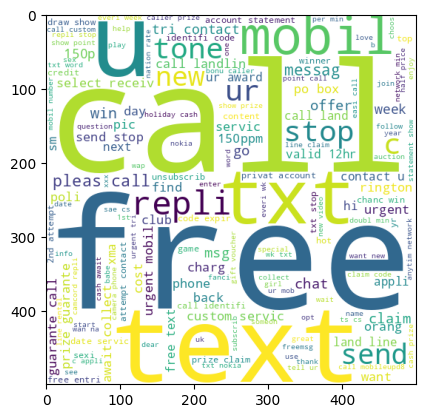

In [32]:
plt.imshow(spam_wc)

In [33]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

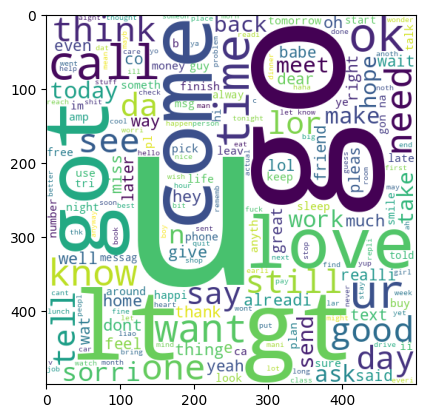

In [34]:
plt.imshow(ham_wc)

In [35]:
spam_list = []
for msg in df[df['target']==1]['transformed_text'].tolist():
  for word in msg.split():
    spam_list.append(word)

len(spam_list)

9939

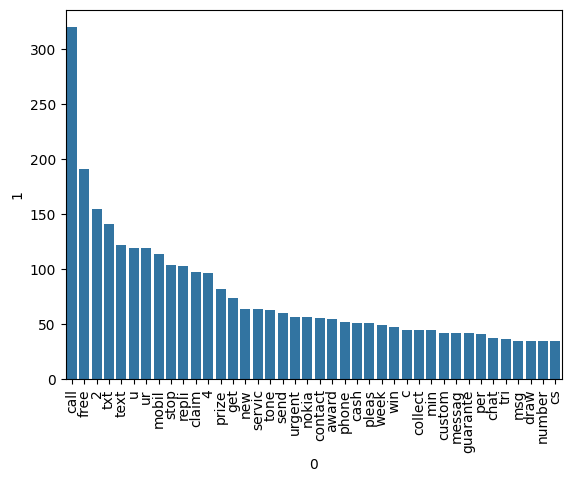

In [36]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_list).most_common(40))[0], y=pd.DataFrame(Counter(spam_list).most_common(40))[1])
plt.xticks(rotation='vertical')
plt.show()

In [37]:
ham_list = []
for msg in df[df['target']==0]['transformed_text'].tolist():
  for word in msg.split():
    ham_list.append(word)

len(ham_list)

35404

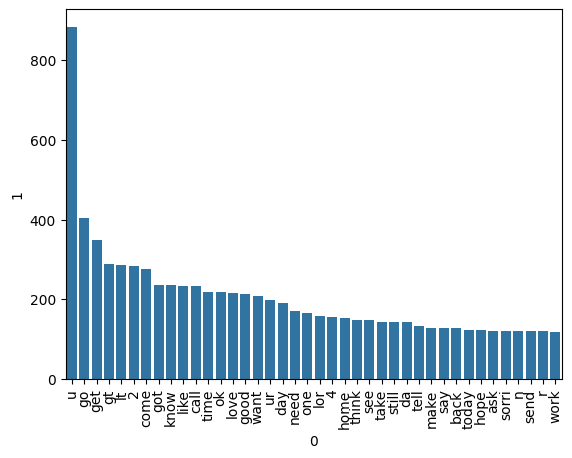

In [38]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_list).most_common(40))[0], y=pd.DataFrame(Counter(ham_list).most_common(40))[1])
plt.xticks(rotation='vertical')
plt.show()

Model Building

In [39]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [40]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [41]:
#Appending the num_char column to X
#X = np.hstack((X,df['num_char'].values.reshape(-1,1)))

In [42]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
X.shape

(5169, 3000)

In [43]:
Y = df['target'].values

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [45]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [46]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [47]:
#Gaussian Naive Bayes
gnb.fit(X_train, Y_train)
Y_pred1 = gnb.predict(X_test)
print(accuracy_score(Y_test, Y_pred1))
print(confusion_matrix(Y_test, Y_pred1))
print(precision_score(Y_test, Y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [48]:
#Multinomial Naive Bayes
mnb.fit(X_train, Y_train)
Y_pred2 = mnb.predict(X_test)
print(accuracy_score(Y_test, Y_pred2))
print(confusion_matrix(Y_test, Y_pred2))
print(precision_score(Y_test, Y_pred2))
print(mnb.predict(X_test[:5]))

#We have used TfidfVectorizer and applying MultinomialNB significantly improved the precision score so we will procees with this.

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [74]:
from sklearn.utils.validation import check_is_fitted

# Ensure mnb is fitted before checking. It was likely re-initialized in a later cell.
# X_train and Y_train are available from previous cells.
mnb.fit(X_train, Y_train)

check_is_fitted(mnb)
print("MNB FITTED")

MNB FITTED


In [49]:
#Bernoulli Naive Bayes
bnb.fit(X_train, Y_train)
Y_pred3 = bnb.predict(X_test)
print(accuracy_score(Y_test, Y_pred3))
print(confusion_matrix(Y_test, Y_pred3))
print(precision_score(Y_test, Y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [50]:
#Testing other algorithms in comparison to MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [51]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [52]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [53]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train, Y_train)
    Y_pred = clf.predict(X_test)
    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)

    return accuracy, precision

In [54]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():

    current_accuracy, current_precision = train_classifier(clf, X_train, Y_train, X_test, Y_test)

    print("For ",name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9323017408123792
Precision -  0.8333333333333334
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96
For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [55]:
#performance_df = pd.DataFrame({'Algorithm':clfs.keys(), 'Accuracy':accuracy_scores, 'Precision':precision_scores}).sort_values('Precision',ascending=False)
#performance_df

In [56]:
#performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")
#performance_df1

In [57]:
#sns.catplot(x = 'Algorithm', y='value', hue = 'variable', data = performance_df1, kind='bar',height=5)
#plt.ylim(0.5,1.0)
#plt.xticks(rotation='vertical')
#plt.show()

In [58]:
#Improvement of Model Performance

In [59]:
#temp_df = pd.DataFrame({'Algorithm': clfs.keys(), 'Accuracy_max_ft_3000': accuracy_scores, 'Precision_max_ft_3000': precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)
#temp_df

In [60]:
#new_df = performance_df.merge(temp_df, on = 'Algorithm')
#new_df

In [61]:
#temp_df_scaled = pd.DataFrame({'Algorithm': clfs.keys(),'Accuracy_scaling': accuracy_scores, 'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)
#temp_df_scaled

In [62]:
#new_df_scaled = new_df.merge(temp_df_scaled, on = 'Algorithm')
#new_df_scaled

In [63]:
#temp_df_num_char = pd.DataFrame({'Algorithm': clfs.keys(),'Accuracy_num_chars': accuracy_scores, 'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)
#temp_df_num_char

In [64]:
#new_df_scaled.merge(temp_df_num_char, on='Algorithm')

In [65]:
#Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [66]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')
voting.fit(X_train, Y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [67]:
VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [68]:
Y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(Y_test, Y_pred))
print("Precision",precision_score(Y_test, Y_pred))

Accuracy 0.9796905222437138
Precision 0.9834710743801653


In [69]:
#Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [70]:
from sklearn.ensemble import StackingClassifier

In [71]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
clf.fit(X_train, Y_train)
Y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(Y_test, Y_pred))
print("Precision",precision_score(Y_test, Y_pred))

Accuracy 0.9796905222437138
Precision 0.9465648854961832


In [75]:
mnb = MultinomialNB()
mnb.fit(X_train, Y_train)

import pickle
pickle.dump(tfidf, open('vectorizer.pkl','wb'))
pickle.dump(mnb, open('model.pkl','wb'))